In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [2]:
import numpy as np
from scipy.signal import find_peaks

def pan_tompkins_r_peak_detection(ecg_signal, fs=100):
    """
    Apply the Pan-Tompkins algorithm for R-peak detection in ECG signal.
    """
    # Step 1: Differentiation
    diff_ecg = np.diff(ecg_signal)
    
    # Step 2: Squaring
    squared_ecg = diff_ecg ** 2
    
    # Step 3: Moving Window Integration (MWI)
    window_size = int(0.150 * fs)
    mwi_ecg = np.convolve(squared_ecg, np.ones(window_size)/window_size, mode='same')
    
    # Step 4: Thresholding
    threshold = 0.6 * np.max(mwi_ecg)
    # Ensure minimum distance between peaks (0.6s * fs)
    r_peaks, _ = find_peaks(mwi_ecg, height=threshold, distance=int(0.6 * fs))
    
    return r_peaks

def extract_heartbeats(X, max_len=20, window_len=100, fs=100):
    """
    Extract heartbeats using Pan-Tompkins. If fewer beats are detected than max_beats,
    existing beats are repeated (cyclically) instead of padding with zeros.
    """
    
    B, C, L = X.shape  # (Batch, Channels, Length)
    
    # --- Pass 1: Determine Max Beats ---
    max_beats = max_len
    all_r_peaks = [] # Cache r_peaks to avoid re-calculating in Pass 2
    
    for i in range(B):
        # Extract Lead II (index 1) for detection
        lead_ii = X[i, 1, :]
        r_peaks = pan_tompkins_r_peak_detection(lead_ii, fs)
        all_r_peaks.append(r_peaks)
        max_beats = max(max_beats, len(r_peaks))
    
    # Safety fallback if no peaks detected in entire batch
    if max_beats == 0:
        max_beats = 1 

    # Initialize output array
    heartbeats_array = np.zeros((B, max_beats, C, window_len))
    
    window_ratio = 0.4
    
    # --- Pass 2: Extract and Pad ---
    for i in range(B):
        r_peaks = all_r_peaks[i]
        beats = []
        
        # 1. Extract valid beats
        for peak in r_peaks:
            start = max(peak - int(window_len * window_ratio), 0)
            end = min(peak + int(window_len * (1 - window_ratio)), L)
            heartbeat = X[i, :, start:end]
            
            # Skip incomplete windows at edges
            if heartbeat.shape[1] < window_len:
                continue
            
            beats.append(heartbeat)
        
        # 2. Handle Padding (Repetition Logic)
        num_detected = len(beats)
        
        if num_detected == 0:
            # Edge Case: No beats found in this specific sample.
            # We must pad with zeros or noise to maintain shape, 
            # though this is rare with good data.
            for j in range(max_beats):
                beats.append(np.zeros((C, window_len)))
        
        elif num_detected < max_beats:
            # Main Logic: Repeat existing beats cyclically
            # If we have [A, B] and need 5 total, we append A, B, A -> [A, B, A, B, A]
            needed = max_beats - num_detected
            for j in range(needed):
                # Use modulo to cycle through valid beats
                beat_to_repeat = beats[j % num_detected]
                beats.append(beat_to_repeat)
        
        # If we somehow have too many (rare due to Pass 1 logic, but possible if edges were skipped), trim
        beats = beats[:max_beats]
        
        heartbeats_array[i] = np.array(beats)
    
    # Transpose to (B, C, Beats, Time)
    return heartbeats_array.transpose(0, 2, 1, 3)

In [3]:
import scipy.signal as signal
def filter_signal(signal_data, axis=0, fs=100, lowcut=0.5, highcut=45.0):
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        return signal.filtfilt(b, a, signal_data, axis=axis)

def normalize_min_max(arr, epsilon=1e-8):
    # Normalize the last dimension (axis=-1) using min-max normalization
    min_vals = arr.min(axis=-1, keepdims=True)
    max_vals = arr.max(axis=-1, keepdims=True)
    
    # Add epsilon to prevent division by zero for flat/padded signals
    normalized_arr = (arr - min_vals) / (max_vals - min_vals + epsilon)
    
    # Optional: Fill any remaining NaNs with 0 just in case
    normalized_arr = np.nan_to_num(normalized_arr)
    
    return normalized_arr

In [4]:
import scipy.signal as signal
def filter_signal(signal_data, axis=0, fs=100, lowcut=0.5, highcut=45.0):
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        return signal.filtfilt(b, a, signal_data, axis=axis)

def normalize_min_max(arr, epsilon=1e-8):
    # Normalize the last dimension (axis=-1) using min-max normalization
    min_vals = arr.min(axis=-1, keepdims=True)
    max_vals = arr.max(axis=-1, keepdims=True)
    
    # Add epsilon to prevent division by zero for flat/padded signals
    normalized_arr = (arr - min_vals) / (max_vals - min_vals + epsilon)
    
    # Optional: Fill any remaining NaNs with 0 just in case
    normalized_arr = np.nan_to_num(normalized_arr)
    
    return normalized_arr

In [5]:
# import os
# import numpy as np
# import pandas as pd
# import scipy.io
# from scipy import signal
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MultiLabelBinarizer

# # ==========================================
# # 1. CONFIGURATION
# # ==========================================
# superclass_dict = {
#     'NORM': ['NORM'],
#     'CD':   ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'IVCB'],
#     'HYP':  ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
#     'MI':   ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
#     'STTC': ['ISC_', 'STTC', 'NST_']
# }

# georgia_to_ptbxl_map = {
#     '426783006': 'NORM',
#     '164909002': 'CLBBB',
#     '59118001':  'CRBBB',
#     '270492004': '_AVB',  
#     '164873001': 'LVH',
#     '89792004':  'RVH',
#     '164934002': 'STTC',
#     # New Classes
#     '164889003': 'AFIB', 
#     '284470004': 'PAC',    
#     '427172004': 'PVC',    
#     '426177001': 'SB',     
#     '427084000': 'STach',  
#     '270492004': 'AFL'     
# }

# # ==========================================
# # 2. HELPER FUNCTIONS
# # ==========================================
# def append_csv_file_strict(file_path, new_df):
#     """
#     Appends new data to CSV with STRICT column ordering:
#     1. ecg_id is always first.
#     2. All other columns are aligned and filled with 0.
#     """
#     if os.path.exists(file_path):
#         existing_df = pd.read_csv(file_path)
        
#         # 1. Align Columns
#         all_cols = list(set(existing_df.columns) | set(new_df.columns))
        
#         existing_df = existing_df.reindex(columns=all_cols, fill_value=0)
#         new_df = new_df.reindex(columns=all_cols, fill_value=0)
        
#         # 2. Concat
#         combined_df = pd.concat([existing_df, new_df], axis=0, ignore_index=True)
#         combined_df = combined_df.fillna(0)
        
#         # 3. Force Column Order: ecg_id first, then alphabetical
#         if 'ecg_id' in combined_df.columns:
#             cols = ['ecg_id'] + sorted([c for c in combined_df.columns if c != 'ecg_id'])
#             combined_df = combined_df[cols]
            
#         combined_df.to_csv(file_path, index=False)
#         print(f"  [CSV] Appended to {os.path.basename(file_path)}. Shape: {combined_df.shape}")
            
#     else:
#         # If creating new file, still enforce order
#         if 'ecg_id' in new_df.columns:
#             cols = ['ecg_id'] + sorted([c for c in new_df.columns if c != 'ecg_id'])
#             new_df = new_df[cols]
            
#         new_df.to_csv(file_path, index=False)
#         print(f"  [CSV] Created {os.path.basename(file_path)}.")

# def append_numpy_file(file_path, new_data):
#     """
#     Appends numpy data. Expected format: (Batch, Length, Channels)
#     """
#     if os.path.exists(file_path):
#         existing = np.load(file_path)
        
#         # Safety Check: Ensure dimensions match (except batch dim)
#         if existing.shape[1:] != new_data.shape[1:]:
#              raise ValueError(f"Shape Mismatch! Existing: {existing.shape}, New: {new_data.shape}. Expected (B, L, C).")

#         combined = np.concatenate([existing, new_data], axis=0)
#         np.save(file_path, combined)
#         print(f"  [NPY] Appended to {os.path.basename(file_path)}. New Shape: {combined.shape}")
#     else:
#         np.save(file_path, new_data)
#         print(f"  [NPY] Created {os.path.basename(file_path)}. Shape: {new_data.shape}")

# # ==========================================
# # 3. MAIN PIPELINE
# # ==========================================
# def process_and_append_georgia(raw_path, output_path):
#     print(f"--- Processing Georgia Data ---")
    
#     records = []
#     labels_list = []
    
#     # 1. Load Data
#     filenames = [f.replace('.hea', '') for f in os.listdir(raw_path) if f.endswith('.hea')]
    
#     for fname in filenames:
#         try:
#             # Labels
#             with open(os.path.join(raw_path, fname + '.hea'), 'r') as f:
#                 header = f.read()
#             dx_codes = []
#             for line in header.split('\n'):
#                 if line.startswith('#Dx:'):
#                     dx_codes = [x.strip() for x in line.split('Dx:')[1].split(',')]
            
#             mapped = [georgia_to_ptbxl_map[c] for c in dx_codes if c in georgia_to_ptbxl_map]
            
#             # Signal
#             mat = scipy.io.loadmat(os.path.join(raw_path, fname + '.mat'))
            
#             # FORMATTING LOGIC:
#             # Raw 'val' is (12, 5000) -> (Channels, Length)
#             # Transpose to (5000, 12) -> (Length, Channels)
#             sig = mat['val'].T  
            
#             # Resample operates on axis=0 (Length) by default
#             # 5000 -> 1000
#             # Result is (1000, 12)
#             sig_100hz = signal.resample(sig, 1000)
            
#             records.append(sig_100hz)
#             labels_list.append(mapped)
            
#         except Exception as e:
#             # print(f"Skip {fname}: {e}")
#             pass

#     X_georgia = np.array(records)
    
#     # --- CONFIRM SHAPE IS (B, L, C) ---
#     # Expected: (N, 1000, 12)
#     print(f"Loaded {len(X_georgia)} valid records.")
#     print(f"Data Shape: {X_georgia.shape} -> (Batch, Length, Channels)")
    
#     if X_georgia.shape[1] != 1000 or X_georgia.shape[2] != 12:
#         print("WARNING: Shape is suspicious! Expected (N, 1000, 12).")

#     # 2. Update Dictionary
#     unique_georgia = set([l for sub in labels_list for l in sub])
#     existing_subs = set([item for sublist in superclass_dict.values() for item in sublist])
#     new_labels = unique_georgia - existing_subs
    
#     if new_labels:
#         print(f"Found new labels: {new_labels}")
#         if 'RHYTHM' not in superclass_dict: superclass_dict['RHYTHM'] = []
#         superclass_dict['RHYTHM'].extend(list(new_labels))

#     # 3. Create DataFrames & ASSIGN ECG_ID
    
#     # Generate IDs starting at 80000
#     start_id = 80000
#     new_ids = np.arange(start_id, start_id + len(X_georgia))
    
#     # T (Subclass)
#     all_sub = [item for sublist in superclass_dict.values() for item in sublist]
#     mlb_sub = MultiLabelBinarizer(classes=all_sub)
#     df_sub = pd.DataFrame(mlb_sub.fit_transform(labels_list), columns=all_sub)
#     df_sub['ecg_id'] = new_ids # Add ID
    
#     # Z (Superclass)
#     super_labels = []
#     for labs in labels_list:
#         cur = set()
#         for l in labs:
#             for k, v in superclass_dict.items():
#                 if l in v: cur.add(k)
#         super_labels.append(list(cur))
        
#     mlb_super = MultiLabelBinarizer(classes=list(superclass_dict.keys()))
#     df_super = pd.DataFrame(mlb_super.fit_transform(super_labels), columns=list(superclass_dict.keys()))
#     df_super['ecg_id'] = new_ids # Add ID

#     # 4. Split and Append
#     indices = np.arange(len(X_georgia))
#     train_idx, test_idx = train_test_split(indices, test_size=0.4, random_state=42)
#     val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=42)
    
#     if not os.path.exists(output_path): os.makedirs(output_path)
    
#     # Note: Using 'valid' in filename to match your loader: Y_valid.npy
#     for name, idx in [('train', train_idx), ('valid', val_idx), ('test', test_idx)]:
#         print(f"\n--- Appending {name} ---")
        
#         append_numpy_file(os.path.join(output_path, f'Y_{name}.npy'), X_georgia[idx])
        
#         # Use STRICT append to fix column order
#         append_csv_file_strict(os.path.join(output_path, f'Z_{name}.csv'), df_super.iloc[idx])
#         append_csv_file_strict(os.path.join(output_path, f'T_{name}.csv'), df_sub.iloc[idx])

# # ==========================================
# # 4. RUN
# # ==========================================
# raw_georgia_path = '../../dataset/georgia' 
# output_folder = '../../source/data_source_multiple' 

# if os.path.exists(raw_georgia_path):
#     process_and_append_georgia(raw_georgia_path, output_folder)
#     print("\nDone.")
# else:
#     print(f"Path not found: {raw_georgia_path}")

In [6]:
import pandas as pd
import numpy as np
import os
from tabulate import tabulate
from scipy import signal

# ==========================================
# 1. UPDATE DICTIONARY WITH NEW CLASSES
# ==========================================
# Added 'RHYTHM' category for the new Georgia labels
superclass_dict = {
    'NORM':   ['NORM'],
    'CD':     ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB'], 
    'HYP':    ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI':     ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC':   ['ISC_', 'STTC', 'NST_'],
    'RHYTHM': ['AFIB', 'PAC', 'SB', 'STach', 'AFL']
}

# Flatten to get valid column names
valid_subclasses = [item for sublist in superclass_dict.values() for item in sublist]
print(f"Selected {len(valid_subclasses)} subclasses: {valid_subclasses}")

path_load = '../../source/data_source_multiple'

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================

def load_and_filter_labels(csv_path, valid_cols):
    """
    Loads CSV, selects only valid columns. 
    If a valid column is missing from the CSV, it creates it with 0s (Safe Loading).
    """
    if not os.path.exists(csv_path):
        print(f"Warning: File not found {csv_path}")
        return np.array([])

    df = pd.read_csv(csv_path)
    
    # 1. Check for missing columns and add them as 0s
    # (This handles the case where PTB-XL didn't have 'AFIB' but we want to train on it)
    for col in valid_cols:
        if col not in df.columns:
            df[col] = 0.0
            
    # 2. Select only valid columns in the correct order
    df_filtered = df[valid_cols]
    return df_filtered.to_numpy(dtype=np.float32)

# ==========================================
# 3. LOAD DATA
# ==========================================

print("Loading Train...")
# 1. Train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = filter_signal(X_train, axis=1, fs=100, lowcut=0.5, highcut=45.0).transpose(0, 2, 1)
heartbeats_train = normalize_min_max(extract_heartbeats(X_train))

# Load Z (Superclass) - Drop ID if exists
y_train_df = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
if 'ecg_id' in y_train_df.columns: y_train_df = y_train_df.drop(columns=['ecg_id'])
# Filter Y to ensure it matches new dictionary keys
y_train = y_train_df[list(superclass_dict.keys())].to_numpy(dtype=np.float32)

# Load T (Subclass)
z_train = load_and_filter_labels(os.path.join(path_load, 'T_train.csv'), valid_subclasses)

print("Loading Test...")
# 2. Test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = filter_signal(X_test, axis=1, fs=100, lowcut=0.5, highcut=45.0).transpose(0, 2, 1)
heartbeats_test = normalize_min_max(extract_heartbeats(X_test))

y_test_df = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
if 'ecg_id' in y_test_df.columns: y_test_df = y_test_df.drop(columns=['ecg_id'])
y_test = y_test_df[list(superclass_dict.keys())].to_numpy(dtype=np.float32)

z_test = load_and_filter_labels(os.path.join(path_load, 'T_test.csv'), valid_subclasses)

print("Loading Validation...")
# 3. Validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = filter_signal(X_val, axis=1, fs=100, lowcut=0.5, highcut=45.0).transpose(0, 2, 1)
heartbeats_val = normalize_min_max(extract_heartbeats(X_val))

y_val_df = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
if 'ecg_id' in y_val_df.columns: y_val_df = y_val_df.drop(columns=['ecg_id'])
y_val = y_val_df[list(superclass_dict.keys())].to_numpy(dtype=np.float32)

z_val = load_and_filter_labels(os.path.join(path_load, 'T_valid.csv'), valid_subclasses)


# ==========================================
# 4. PRINT SHAPES
# ==========================================
table = [
    ["X_train", X_train.shape],
    ["Heartbeats train", heartbeats_train.shape],
    ["y_train (Superclass)", y_train.shape], # Should now have 6 columns (added RHYTHM)
    ["z_train (Subclass)", z_train.shape],   # Should now include AFIB, PAC, etc.
    ["X_test", X_test.shape],
    ["Heartbeats test", heartbeats_test.shape],
    ["y_test (Superclass)", y_test.shape],
    ["z_test (Subclass)", z_test.shape],
    ["X_val", X_val.shape],
    ["Heartbeats val", heartbeats_val.shape],
    ["y_val (Superclass)", y_val.shape],
    ["z_val (Subclass)", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

Selected 26 subclasses: ['NORM', 'LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB', 'LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP', 'AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI', 'ISC_', 'STTC', 'NST_', 'AFIB', 'PAC', 'SB', 'STach', 'AFL']
Loading Train...
Loading Test...
Loading Validation...
+----------------------+----------------------+
| Dataset              | Shape                |
+======================+======================+
| X_train              | (23647, 12, 1000)    |
+----------------------+----------------------+
| Heartbeats train     | (23647, 12, 20, 100) |
+----------------------+----------------------+
| y_train (Superclass) | (23647, 6)           |
+----------------------+----------------------+
| z_train (Subclass)   | (23647, 26)          |
+----------------------+----------------------+
| X_test               | (4272, 12, 1000)     |
+----------------------+----------------------+
| Heartbeats test      | (4272, 12, 20, 100)  |
+----------------------+---------

In [7]:
import pandas as pd

# 1. Load just the header (nrows=0 reads only columns)
df_header = pd.read_csv(os.path.join(path_load, 'T_train.csv'))

# 2. Get the list of columns
all_columns = df_header.columns.tolist()

# 3. Filter out 'ecg_id' to get just the class names
# We assume 'ecg_id' is the first column. 
# If there are other non-class columns (like patient_id), remove them too.
label_map_sub = [col for col in all_columns if col != 'ecg_id']

# 4. Create the mapping (Class Name -> Index)
class_to_idx = {name: idx for idx, name in enumerate(label_map_sub)}

# 5. Create the reverse mapping (Index -> Class Name) - useful for printing results
idx_to_class = {idx: name for idx, name in enumerate(label_map_sub)}

# --- Verify the Output ---
print(f"Total Classes: {len(label_map_sub)}")
print("\nClass to Index Mapping:")
print(class_to_idx)

print("\nMaster List (Copy this to your config):")
print(label_map_sub)

Total Classes: 28

Class to Index Mapping:
{'AFIB': 0, 'AFL': 1, 'AMI': 2, 'CLBBB': 3, 'CRBBB': 4, 'ILBBB': 5, 'IMI': 6, 'IRBBB': 7, 'ISCA': 8, 'ISCI': 9, 'ISC_': 10, 'IVCB': 11, 'LAFB/LPFB': 12, 'LAO/LAE': 13, 'LMI': 14, 'LVH': 15, 'NORM': 16, 'NST_': 17, 'PAC': 18, 'PMI': 19, 'RAO/RAE': 20, 'RVH': 21, 'SB': 22, 'SEHYP': 23, 'STTC': 24, 'STach': 25, 'WPW': 26, '_AVB': 27}

Master List (Copy this to your config):
['AFIB', 'AFL', 'AMI', 'CLBBB', 'CRBBB', 'ILBBB', 'IMI', 'IRBBB', 'ISCA', 'ISCI', 'ISC_', 'IVCB', 'LAFB/LPFB', 'LAO/LAE', 'LMI', 'LVH', 'NORM', 'NST_', 'PAC', 'PMI', 'RAO/RAE', 'RVH', 'SB', 'SEHYP', 'STTC', 'STach', 'WPW', '_AVB']


In [8]:
import pandas as pd
import os
from prettytable import PrettyTable

# ==========================================
# 1. CONFIGURATION
# ==========================================
# The path where your final appended data lives
data_path = '../../source/data_source_multiple'

# The Hierarchy Dictionary (Updated with RHYTHM)
superclass_dict = {
    'NORM':   ['NORM'],
    'CD':     ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB'],
    'HYP':    ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI':     ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC':   ['ISC_', 'STTC', 'NST_'],
    'RHYTHM': ['AFIB', 'PAC', 'SB', 'STach', 'AFL'] 
}

# ==========================================
# 2. HELPER TO LOAD & SUM
# ==========================================
def get_total_counts(path, prefix):
    """
    Loads prefix_train, prefix_val, prefix_test.
    Returns a Series with the sum of all columns across all splits.
    """
    total_counts = pd.Series(dtype=float)
    
    for split in ['train', 'valid', 'test']:
        file_path = os.path.join(path, f'{prefix}_{split}.csv')
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            # Drop ID if present
            if 'ecg_id' in df.columns:
                df = df.drop(columns=['ecg_id'])
            
            # Sum columns (axis=0) and add to running total
            # We use .add(fill_value=0) to handle cases where columns might be missing in one split
            total_counts = total_counts.add(df.sum(), fill_value=0)
        else:
            print(f"Warning: {file_path} not found.")
            
    return total_counts.astype(int)

# ==========================================
# 3. CALCULATE STATS
# ==========================================
if os.path.exists(data_path):
    print("Loading data and calculating sums...")
    
    # Get Counts for Superclasses (Z files)
    super_counts = get_total_counts(data_path, 'Z')
    
    # Get Counts for Subclasses (T files)
    sub_counts = get_total_counts(data_path, 'T')

    # ==========================================
    # 4. BUILD PRETTYTABLE
    # ==========================================
    table = PrettyTable()
    table.field_names = ["Superclass", "Total", "Subclasses (Count)"]
    table.align = "l"  # Align left

    for super_name, sub_list in superclass_dict.items():
        # 1. Get Superclass Total
        s_count = super_counts.get(super_name, 0)
        
        # 2. Build Subclass String (e.g., "AMI (1200)\nIMI (400)")
        sub_str_list = []
        for sub_name in sub_list:
            c_count = sub_counts.get(sub_name, 0)
            sub_str_list.append(f"{sub_name} ({c_count})")
        
        # Join with newlines for the table cell
        formatted_subclasses = "\n".join(sub_str_list)
        
        # 3. Add Row
        table.add_row([super_name, s_count, formatted_subclasses])
        table.add_row(["-"*10, "-"*5, "-"*20]) # Separator line

    print("\ndataset Statistics (All Splits Combined)")
    print(table)

else:
    print(f"Path not found: {data_path}")

Loading data and calculating sums...

dataset Statistics (All Splits Combined)
+------------+-------+----------------------+
| Superclass | Total | Subclasses (Count)   |
+------------+-------+----------------------+
| NORM       | 11280 | NORM (11280)         |
| ---------- | ----- | -------------------- |
| CD         | 5680  | LAFB/LPFB (1800)     |
|            |       | IRBBB (1118)         |
|            |       | ILBBB (77)           |
|            |       | CLBBB (767)          |
|            |       | CRBBB (1084)         |
|            |       | _AVB (827)           |
| ---------- | ----- | -------------------- |
| HYP        | 3960  | LVH (3369)           |
|            |       | RVH (212)            |
|            |       | LAO/LAE (427)        |
|            |       | RAO/RAE (99)         |
|            |       | SEHYP (30)           |
| ---------- | ----- | -------------------- |
| MI         | 5486  | AMI (3086)           |
|            |       | IMI (3281)           |
|

In [9]:
columns_of_csv = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
label_map = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map)

columns_of_csv = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
label_map_sub = {label: i for i, label in enumerate(columns_of_csv.columns[1:])}
print(label_map_sub)

superclass_dict = {
    'NORM': ['NORM'],
    'CD': ['LAFB/LPFB', 'IRBBB', 'ILBBB', 'CLBBB', 'CRBBB', '_AVB'],
    'HYP': ['LVH', 'RVH', 'LAO/LAE', 'RAO/RAE', 'SEHYP'],
    'MI': ['AMI', 'IMI', 'LMI', 'PMI', 'ISCA', 'ISCI'],
    'STTC': ['ISC_', 'STTC', 'NST_'],
    'RHYTHM': ['AFIB', 'PAC', 'SB', 'STach', 'AFL']
}

{'CD': 0, 'HYP': 1, 'MI': 2, 'NORM': 3, 'RHYTHM': 4, 'STTC': 5}


{'AFIB': 0, 'AFL': 1, 'AMI': 2, 'CLBBB': 3, 'CRBBB': 4, 'ILBBB': 5, 'IMI': 6, 'IRBBB': 7, 'ISCA': 8, 'ISCI': 9, 'ISC_': 10, 'IVCB': 11, 'LAFB/LPFB': 12, 'LAO/LAE': 13, 'LMI': 14, 'LVH': 15, 'NORM': 16, 'NST_': 17, 'PAC': 18, 'PMI': 19, 'RAO/RAE': 20, 'RVH': 21, 'SB': 22, 'SEHYP': 23, 'STTC': 24, 'STach': 25, 'WPW': 26, '_AVB': 27}


In [10]:
x_train = torch.from_numpy(heartbeats_train).float()  # float tensor for input
labels_train = torch.from_numpy(y_train).float()  # float tensor for labels
sub_labels_train = torch.from_numpy(z_train).float()

x_val = torch.from_numpy(heartbeats_val).float()
labels_val = torch.from_numpy(y_val).float()
sub_labels_val = torch.from_numpy(z_val).float()

x_test = torch.from_numpy(heartbeats_test).float()
lables_test = torch.from_numpy(y_test).float()
sub_labels_test = torch.from_numpy(z_test).float()

batch_size = 32

train_dataset = TensorDataset(x_train, labels_train, sub_labels_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(x_val, labels_val, sub_labels_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test = TensorDataset(x_test, lables_test, sub_labels_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary

# ---------------------------------------------------------
# 1. Stochastic Depth (DropPath)
#    Advanced regularization: randomly drops residual paths 
#    during training to make the model robust.
# ---------------------------------------------------------
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        # Work with any number of dimensions (broadcasting)
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()  # binarize
        output = x.div(keep_prob) * random_tensor
        return output

# ---------------------------------------------------------
# 2. Multi-Scale Depthwise Conv (MS-DWConv)
#    Splits channels into groups and applies different 
#    kernels to capture both sharp peaks and broad waves.
# ---------------------------------------------------------
class MultiScaleDWConv1D(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # Split features into 4 chunks for multi-scale processing
        self.chunk_dim = dim // 4
        # Handle remainder channels
        self.rem_dim = dim - (self.chunk_dim * 3)
        
        # Scale 1: Fine details (QRS features) - k=3
        self.conv1 = nn.Conv1d(self.chunk_dim, self.chunk_dim, kernel_size=3, padding=1, groups=self.chunk_dim, bias=False)
        # Scale 2: Medium details (P-wave) - k=5
        self.conv2 = nn.Conv1d(self.chunk_dim, self.chunk_dim, kernel_size=5, padding=2, groups=self.chunk_dim, bias=False)
        # Scale 3: Coarse details (T-wave) - k=7
        self.conv3 = nn.Conv1d(self.chunk_dim, self.chunk_dim, kernel_size=7, padding=3, groups=self.chunk_dim, bias=False)
        # Scale 4: Long context (Intervals) - k=9 (or dilated)
        self.conv4 = nn.Conv1d(self.rem_dim, self.rem_dim, kernel_size=9, padding=4, groups=self.rem_dim, bias=False)

    def forward(self, x):
        # Split tensor along channel dimension
        x1, x2, x3, x4 = torch.split(x, [self.chunk_dim, self.chunk_dim, self.chunk_dim, self.rem_dim], dim=1)
        
        out1 = self.conv1(x1)
        out2 = self.conv2(x2)
        out3 = self.conv3(x3)
        out4 = self.conv4(x4)
        
        # Concat back
        out = torch.cat([out1, out2, out3, out4], dim=1)
        return out

# ---------------------------------------------------------
# 3. Advanced Robust Block (ConvNeXt + Multi-Scale)
# ---------------------------------------------------------
class AdvancedRobustBlock1D(nn.Module):
    def __init__(self, dim, drop_path=0.0, layer_scale_init_value=1e-6):
        super().__init__()
        
        # 1. Multi-Scale Spatial Mixing
        self.ms_conv = MultiScaleDWConv1D(dim)
        self.bn = nn.BatchNorm1d(dim)
        
        # 2. Pointwise Expansion (Inverted Bottleneck)
        self.pwconv1 = nn.Linear(dim, 4 * dim) 
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        
        # 3. Layer Scale & Regularization
        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones((dim)), 
                                    requires_grad=True) if layer_scale_init_value > 0 else None
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        
        # 4. ECA Attention (Channel Recalibration)
        #    Using k=5 for efficient interaction
        self.eca = ECAAttention1D(kernel_size=5)

    def forward(self, x):
        input = x
        
        x = self.ms_conv(x)
        x = self.bn(x)
        
        # Permute for Linear Layers (N, C, L) -> (N, L, C)
        x = x.permute(0, 2, 1)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        
        if self.gamma is not None:
            x = self.gamma * x
            
        x = x.permute(0, 2, 1)
        x = self.eca(x)
        
        # DropPath applies to the residual branch
        x = input + self.drop_path(x)
        return x

# ---------------------------------------------------------
# 4. Helper Modules (ECA & Attention Pooling)
#    (Kept same as previous optimized version)
# ---------------------------------------------------------
class ECAAttention1D(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=(kernel_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        y = self.avg_pool(x).transpose(-1, -2)
        y = self.conv(y)
        y = self.sigmoid(y.transpose(-1, -2))
        return x * y

class AttentionPooling(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(in_dim, in_dim // 2),
            nn.Tanh(),
            nn.Linear(in_dim // 2, 1)
        )
    def forward(self, x):
        scores = self.attention(x)
        weights = F.softmax(scores, dim=1)
        weighted_features = torch.sum(x * weights, dim=1)
        return weighted_features, weights

# ---------------------------------------------------------
# 5. Advanced Context Adapter
#    Injects Superclass Knowledge into Subclass Features
# ---------------------------------------------------------
class ContextAwareAdapter(nn.Module):
    def __init__(self, feat_dim, context_dim):
        super().__init__()
        # We fuse Global Features + Superclass Logits/Embeddings
        input_dim = feat_dim + context_dim
        
        self.norm = nn.LayerNorm(feat_dim)
        
        # Project context to feature space first
        self.context_proj = nn.Linear(context_dim, feat_dim)
        self.act_ctx = nn.SiLU()
        
        # Refinement MLP
        self.fc1 = nn.Linear(feat_dim, feat_dim * 2)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(feat_dim * 2, feat_dim)
        
        # Gating mechanism within the adapter
        self.gate = nn.Sequential(
            nn.Linear(feat_dim * 2, feat_dim),
            nn.Sigmoid()
        )

    def forward(self, x, context_logits):
        # x: (B, Feat_Dim)
        # context_logits: (B, Num_Superclasses)
        
        identity = x
        x = self.norm(x)
        
        # 1. Inject Context
        # Project logits to feature space
        ctx = self.act_ctx(self.context_proj(context_logits))
        
        # Add context to features (Conditioning)
        x_ctx = x + ctx 
        
        # 2. Refine
        out = self.fc1(x_ctx)
        out = self.act(out)
        out = self.dropout(out)
        
        # 3. Self-Gating (GLU-style)
        # Learn what to keep based on the new context
        gate = self.gate(out) # derived from hidden layer
        val = self.fc2(out)
        
        out = val * gate
        
        return identity + out

# ---------------------------------------------------------
# 6. Main Network
# ---------------------------------------------------------
class AdvancedECGNet(nn.Module):
    def __init__(self, num_superclasses=5, num_subclasses=23, in_channels=12, 
                 dims=[32, 64, 128], depths=[2, 2, 6], drop_path_rate=0.2):
        super().__init__()
        
        # --- 1. Beat Feature Extractor ---
        # Advanced Stem: Double Conv to capture initial transients better
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, dims[0], kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(dims[0]),
            nn.GELU()
        )
        
        self.stages = nn.ModuleList()
        curr_dim = dims[0]
        
        # Stochastic Depth decay rule (linearly increasing drop probability)
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))] 
        cur = 0
        
        for i in range(3):
            # Downsample
            if i > 0:
                downsample = nn.Sequential(
                    nn.BatchNorm1d(curr_dim),
                    nn.Conv1d(curr_dim, dims[i], kernel_size=2, stride=2)
                )
                curr_dim = dims[i]
            else:
                downsample = nn.Identity()
            
            blocks = nn.Sequential(*[
                AdvancedRobustBlock1D(
                    dim=curr_dim, 
                    drop_path=dpr[cur + j]
                ) for j in range(depths[i])
            ])
            cur += depths[i]
            
            self.stages.append(nn.Sequential(downsample, blocks))
            
        self.global_pool_1d = nn.AdaptiveAvgPool1d(1)
        
        # --- 2. Beat Aggregator ---
        last_dim = dims[-1]
        self.beat_attention = AttentionPooling(last_dim)
        
        # --- 3. Superclass Head ---
        self.fc_superclass = nn.Sequential(
            nn.LayerNorm(last_dim),
            nn.Linear(last_dim, last_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(last_dim, num_superclasses)
        )
        
        # --- 4. Subclass Path (Context Injection) ---
        
        # Replaces the old adapter + simple gate
        # Now the adapter takes the superclass logits as INPUT
        self.context_adapter = ContextAwareAdapter(
            feat_dim=last_dim, 
            context_dim=num_superclasses
        )
        
        self.fc_subclass = nn.Sequential(
            nn.LayerNorm(last_dim),
            nn.Linear(last_dim, last_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(last_dim, num_subclasses)
        )

    def forward(self, x):
        B, C, Beats, T = x.size()
        
        # 1. Fold
        x = x.permute(0, 2, 1, 3).contiguous().view(B * Beats, C, T)
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        x = self.global_pool_1d(x).flatten(1)
        x = x.view(B, Beats, -1)
        
        # 2. Aggregation
        global_features, _ = self.beat_attention(x)
        
        # 3. Superclass Prediction
        superclass_logits = self.fc_superclass(global_features)
        
        # 4. Context-Aware Subclass Refinement
        # Inject superclass logits directly into the feature refinement process
        # "Given that we think this is [MI], refine the features to find [AMI/IMI]"
        subclass_features = self.context_adapter(global_features, superclass_logits)
        
        # 5. Final Prediction
        subclass_logits = self.fc_subclass(subclass_features)
        
        return superclass_logits, subclass_logits

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Auto-detect number of subclasses from your previous data processing step
# If running fresh, replace num_new_subclasses with literal integer (e.g., 10)
num_new_subclasses = z_train.shape[1]
try:
    num_subs = num_new_subclasses 
except NameError:
    num_subs = 10

model = AdvancedECGNet(
    num_superclasses=5, 
    num_subclasses=num_subs,
    in_channels=12
).to(device)

summary(model, 
        input_size=(1, 12, 20, 100), 
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Mult-Adds
BagOfBeatsECGNet (BagOfBeatsECGNet)                          [1, 12, 20, 100]     [1, 6]               --                   --
├─Sequential (stem)                                          [20, 12, 100]        [20, 32, 50]         --                   --
│    └─Conv1d (0)                                            [20, 12, 100]        [20, 32, 50]         1,568                1,568,000
│    └─BatchNorm1d (1)                                       [20, 32, 50]         [20, 32, 50]         64                   1,280
│    └─GELU (2)                                              [20, 32, 50]         [20, 32, 50]         --                   --
├─ModuleList (stages)                                        --                   --                   --                   --
│    └─Sequential (0)                                        [20, 32, 50]         [20, 32, 50]

In [12]:
def multi_task_loss(output_main, target_main, output_aux, target_aux, model):
    criterion = nn.BCEWithLogitsLoss()
    loss_main = criterion(output_main, target_main)
    loss_aux = criterion(output_aux, target_aux)

    #weighted_loss = (main_weight * weights[0] * loss_main) + (aux_weight * weights[1] * loss_aux)
    #weighted_loss = (lambda_weight * loss_main) + ((1-lambda_weight) * loss_aux)
    weighted_loss = (loss_main) + (loss_aux)

    return weighted_loss, loss_main.item(), loss_aux.item()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

In [13]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch

# 4. Training loop
num_epochs = 30
best_val_loss = float('inf')
best_model_wts = None  # To save the best model

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_main_loss = 0.0
    train_aux_loss = 0.0
    
    # Accumulators for training metrics
    train_preds_main, train_targets_main = [], []
    train_preds_aux, train_targets_aux = [], []

    for inputs, targets, sub_targets in train_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)

        optimizer.zero_grad()
        outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
        loss, train_lm, train_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        train_main_loss += train_lm * inputs.size(0)
        train_aux_loss += train_la * inputs.size(0)

        # --- Collect Predictions for Metrics ---
        with torch.no_grad():
            # Apply Sigmoid and Threshold
            preds_m = (torch.sigmoid(outputs_main) > 0.5).int()
            preds_a = (torch.sigmoid(outputs_aux) > 0.5).int()
            
            # Move to CPU and append
            train_preds_main.append(preds_m.cpu().numpy())
            train_targets_main.append(targets.cpu().numpy())
            train_preds_aux.append(preds_a.cpu().numpy())
            train_targets_aux.append(sub_targets.cpu().numpy())

    # Average Losses
    train_loss /= len(train_loader.dataset)
    train_main_loss /= len(train_loader.dataset)
    train_aux_loss /= len(train_loader.dataset)

    # --- Calculate Training Metrics ---
    train_preds_main = np.vstack(train_preds_main)
    train_targets_main = np.vstack(train_targets_main)
    
    train_acc = accuracy_score(train_targets_main, train_preds_main)
    train_f1 = f1_score(train_targets_main, train_preds_main, average='macro', zero_division=0)

    # Validation
    model.eval()
    val_loss = 0.0
    val_main_loss = 0.0
    val_aux_loss = 0.0
    
    # Accumulators for validation metrics
    val_preds_main, val_targets_main = [], []

    with torch.no_grad():
        for inputs, targets, sub_targets in val_loader:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            
            outputs_main, outputs_aux = model(inputs)  # CNN expects (batch, channels, seq_len)
            loss_, val_lm, val_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
            val_loss += loss_.item() * inputs.size(0)
            val_main_loss += val_lm * inputs.size(0)
            val_aux_loss += val_la * inputs.size(0)
            
            # --- Collect Predictions for Metrics ---
            preds_m = (torch.sigmoid(outputs_main) > 0.5).int()
            val_preds_main.append(preds_m.cpu().numpy())
            val_targets_main.append(targets.cpu().numpy())

    # Average Losses
    val_loss /= len(val_loader.dataset)
    val_main_loss /= len(val_loader.dataset)
    val_aux_loss /= len(val_loader.dataset)
    
    # --- Calculate Validation Metrics ---
    val_preds_main = np.vstack(val_preds_main)
    val_targets_main = np.vstack(val_targets_main)
    
    val_acc = accuracy_score(val_targets_main, val_preds_main)
    val_f1 = f1_score(val_targets_main, val_preds_main, average='macro', zero_division=0)

    # Print with color and progress bar
    epoch_str = f"\033[1;36mEpoch {epoch+1}/{num_epochs}\033[0m"
    bar_len = 30
    filled_len = int(round(bar_len * (epoch+1) / float(num_epochs)))
    bar = '=' * filled_len + '-' * (bar_len - filled_len)
    
    print(f"{epoch_str} [{bar}]")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train Acc:  {train_acc:.4f} | Val Acc:  {val_acc:.4f}")
    print(f"Train F1:   {train_f1:.4f} | Val F1:   {val_f1:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"\033[1;32mFound best save with Val Loss: {val_loss:.4f}\033[0m")
        best_model_wts = model.state_dict()  # Save the best model
        
# --- Test Phase ---
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    
model.eval()
test_loss = 0.0
test_preds_main, test_targets_main = [], []

with torch.no_grad():
    for inputs, targets, sub_targets in test_loader:
        inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
        
        outputs_main, outputs_aux = model(inputs)
        loss, test_lm, test_la = multi_task_loss(outputs_main, targets, outputs_aux, sub_targets, model)
        test_loss += loss.item() * inputs.size(0)
        
        # --- Collect Predictions ---
        preds_m = (torch.sigmoid(outputs_main) > 0.5).int()
        test_preds_main.append(preds_m.cpu().numpy())
        test_targets_main.append(targets.cpu().numpy())

test_loss /= len(test_loader.dataset)

# --- Calculate Test Metrics ---
test_preds_main = np.vstack(test_preds_main)
test_targets_main = np.vstack(test_targets_main)

test_acc = accuracy_score(test_targets_main, test_preds_main)
test_f1 = f1_score(test_targets_main, test_preds_main, average='macro', zero_division=0)

print("-" * 50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc:  {test_acc:.4f}")
print(f"Test F1:   {test_f1:.4f}")
print("-" * 50)

Epoch 1/30 [=-----------------------------]
Train Loss: 0.5297 | Val Loss: 0.4969
Train Acc:  0.3529 | Val Acc:  0.3576
Train F1:   0.3118 | Val F1:   0.3882
Found best save with Val Loss: 0.4969
Epoch 2/30 [==----------------------------]
Train Loss: 0.4544 | Val Loss: 0.4673
Train Acc:  0.4428 | Val Acc:  0.3993
Train F1:   0.4355 | Val F1:   0.4378
Found best save with Val Loss: 0.4673
Epoch 3/30 [===---------------------------]
Train Loss: 0.4322 | Val Loss: 0.4544
Train Acc:  0.4638 | Val Acc:  0.4137
Train F1:   0.4830 | Val F1:   0.4494
Found best save with Val Loss: 0.4544
Epoch 4/30 [====--------------------------]
Train Loss: 0.4172 | Val Loss: 0.4446
Train Acc:  0.4783 | Val Acc:  0.3996
Train F1:   0.5089 | Val F1:   0.4420
Found best save with Val Loss: 0.4446
Epoch 5/30 [=====-------------------------]
Train Loss: 0.4068 | Val Loss: 0.4413
Train Acc:  0.4893 | Val Acc:  0.4392
Train F1:   0.5308 | Val F1:   0.5174
Found best save with Val Loss: 0.4413
Epoch 6/30 [======--

KeyboardInterrupt: 

In [17]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import numpy as np
from tabulate import tabulate

def performance_evaluation(model, dataset, dataset_name, label_map, label_map_sub):
    
    all_targets = []
    all_preds = []
    all_sub_targets = []
    all_sub_preds = []

    model.eval()
    with torch.no_grad():
        for inputs, targets, sub_targets in dataset:
            inputs, targets, sub_targets = inputs.to(device), targets.to(device), sub_targets.to(device)
            outputs_main, output_aux = model(inputs)
            
            probs = torch.sigmoid(outputs_main)
            preds = (probs > 0.5).int()
            
            probs_sub = torch.sigmoid(output_aux)
            preds_sub = (probs_sub > 0.5).int()

            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_sub_targets.append(sub_targets.cpu().numpy())
            all_sub_preds.append(preds_sub.cpu().numpy())

    all_targets = np.vstack(all_targets)
    all_preds = np.vstack(all_preds)
    all_sub_targets = np.vstack(all_sub_targets)
    all_sub_preds = np.vstack(all_sub_preds)
    
    # --- SAFETY CHECK ---
    if all_targets.shape[1] != len(label_map):
        print(f"WARNING: Main output shape {all_targets.shape[1]} != Label Map length {len(label_map)}")
        # Fallback to prevent crash
        loop_limit_main = min(all_targets.shape[1], len(label_map))
    else:
        loop_limit_main = len(label_map)
        
    if all_sub_targets.shape[1] != len(label_map_sub):
        print(f"WARNING: Subclass output shape {all_sub_targets.shape[1]} != Label Map length {len(label_map_sub)}")
        # Fallback to prevent crash
        loop_limit_sub = min(all_sub_targets.shape[1], len(label_map_sub))
    else:
        loop_limit_sub = len(label_map_sub)

    # Prepare table data
    table_data = []
    table_sub_data = []
    headers = ["Class", "Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "TN", "FP", "FN", "TP"]

    # --- Main Class Loop ---
    for i in range(loop_limit_main):
        key = list(label_map.keys())[i] # Get name safely
        y_true = all_targets[:, i]
        y_pred = all_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_data.append([key, f"{precision:.4f}", f"{recall:.4f}", f"{specificity:.4f}", f"{f1_score:.4f}", TN_str, FP_str, FN_str, TP_str])

    # --- Subclass Loop ---
    for i in range(loop_limit_sub):
        key = list(label_map_sub.keys())[i] # Get name safely
        y_true = all_sub_targets[:, i]
        y_pred = all_sub_preds[:, i]

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        if cm.size == 4:
            TN, FP, FN, TP = cm.ravel()
            total = TN + FP + FN + TP
            specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
            f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
            TN_str = f"{TN} ({TN/total*100:.1f}%)"
            FP_str = f"{FP} ({FP/total*100:.1f}%)"
            FN_str = f"{FN} ({FN/total*100:.1f}%)"
            TP_str = f"{TP} ({TP/total*100:.1f}%)"
        else:
            TN_str = FP_str = FN_str = TP_str = "0 (0.0%)"
            specificity = 0.0

        table_sub_data.append([key, f"{precision:.4f}", f"{recall:.4f}", f"{specificity:.4f}", f"{f1_score:.4f}", TN_str, FP_str, FN_str, TP_str])

    print(f"\n------------Performance Evaluation Metrics per Class({dataset_name}) -----------\n")
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    print(tabulate(table_sub_data, headers=headers, tablefmt="grid"))
    
    return all_targets, all_preds

In [18]:
# 1. Generate the correct map for your filtered data
valid_subclasses = [item for sublist in superclass_dict.values() for item in sublist]
new_sub_map = {label: i for i, label in enumerate(valid_subclasses)}

# 2. Pass this map explicitly to the function
targets_train, preds_train = performance_evaluation(model, train_loader, "Train Set", label_map, new_sub_map)
targets_val, preds_val = performance_evaluation(model, val_loader, "Val Set", label_map, new_sub_map)
targets_test, preds_test = performance_evaluation(model, test_loader, "Test Set", label_map, new_sub_map)


------------Performance Evaluation Metrics per Class(Train Set) -----------

+---------+-------------+------------------------+---------------+------------+---------------+-------------+-------------+--------------+
| Class   |   Precision |   Recall (Sensitivity) |   Specificity |   F1-Score | TN            | FP          | FN          | TP           |
+=========+=============+========================+===============+============+===============+=============+=============+==============+
| CD      |      0.8787 |                 0.8931 |        0.9286 |     0.8859 | 13904 (58.8%) | 1069 (4.5%) | 927 (3.9%)  | 7747 (32.8%) |
+---------+-------------+------------------------+---------------+------------+---------------+-------------+-------------+--------------+
| HYP     |      0.8509 |                 0.743  |        0.9704 |     0.7933 | 18700 (79.1%) | 570 (2.4%)  | 1125 (4.8%) | 3252 (13.8%) |
+---------+-------------+------------------------+---------------+------------+---------

In [16]:
def plot_confusion_matrix_per_class_multi(y_true_list, y_pred_list, class_names=None, set_names=None):
    """
    Plot confusion matrices for multiple sets (e.g., test, val, train) in columns.
    y_true_list, y_pred_list: list of arrays, each for a set.
    set_names: list of names for each set.
    """
    metric_label = ["TN", "FP", "FN", "TP"]
    num_sets = len(y_true_list)
    num_classes = y_true_list[0].shape[1]
    if set_names is None:
        set_names = [f"Set {i+1}" for i in range(num_sets)]
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    for class_idx in range(num_classes):
        fig, axes = plt.subplots(1, num_sets, figsize=(5*num_sets, 4))
        if num_sets == 1:
            axes = [axes]
        for set_idx in range(num_sets):
            y_true = y_true_list[set_idx][:, class_idx]
            y_pred = y_pred_list[set_idx][:, class_idx]
            cm = confusion_matrix(y_true, y_pred)
            total = np.sum(cm)
            if cm.size == 4:
                annot = np.empty_like(cm).astype(str)
                for r in range(2):
                    for c in range(2):
                        count = cm[r, c]
                        row_sum = np.sum(cm[r, :])
                        row_percent = 100 * count / row_sum if row_sum > 0 else 0
                        annot[r, c] = f"{count}\n({metric_label[r*2+c]}:{row_percent:.1f}%)"
            else:
                annot = cm
            sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False,
                        xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'],
                        ax=axes[set_idx])
            axes[set_idx].set_title(f"{set_names[set_idx]}")
            axes[set_idx].set_xlabel('Predicted label')
            axes[set_idx].set_ylabel('True label')
        plt.suptitle(f'Confusion Matrix - {class_names[class_idx]}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

confusion_matrix (Test Set)


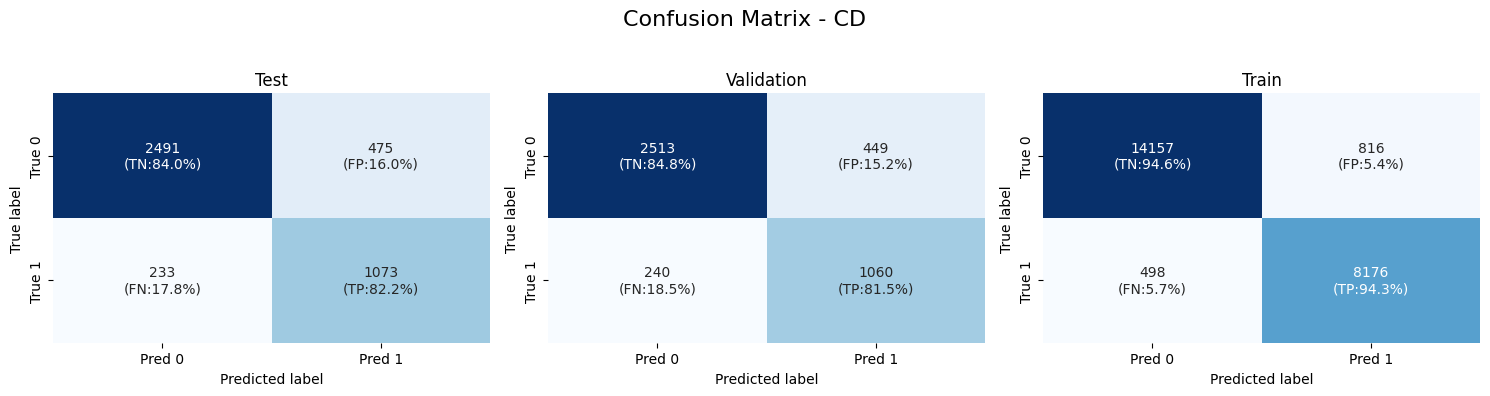

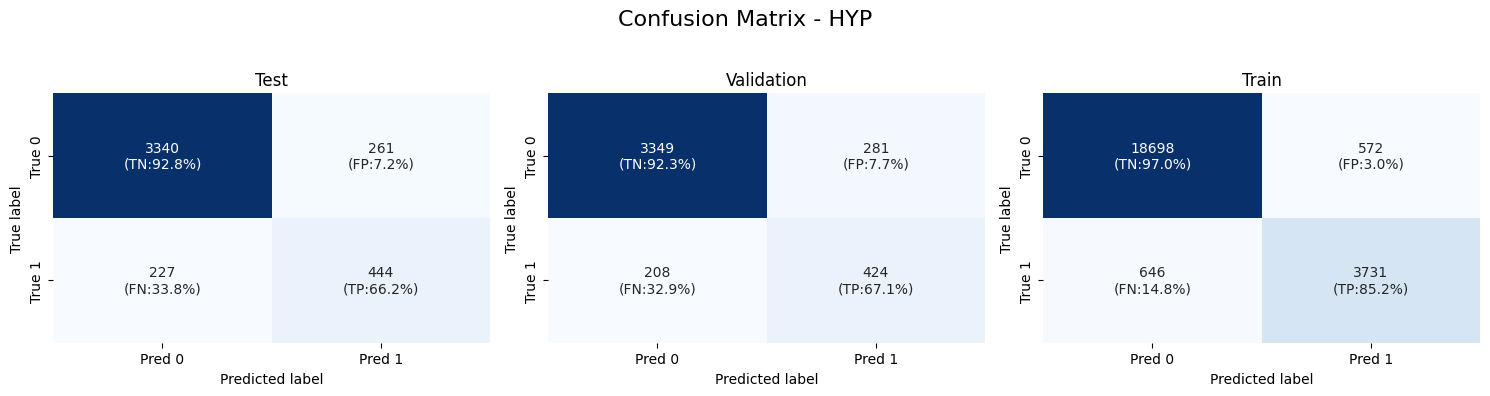

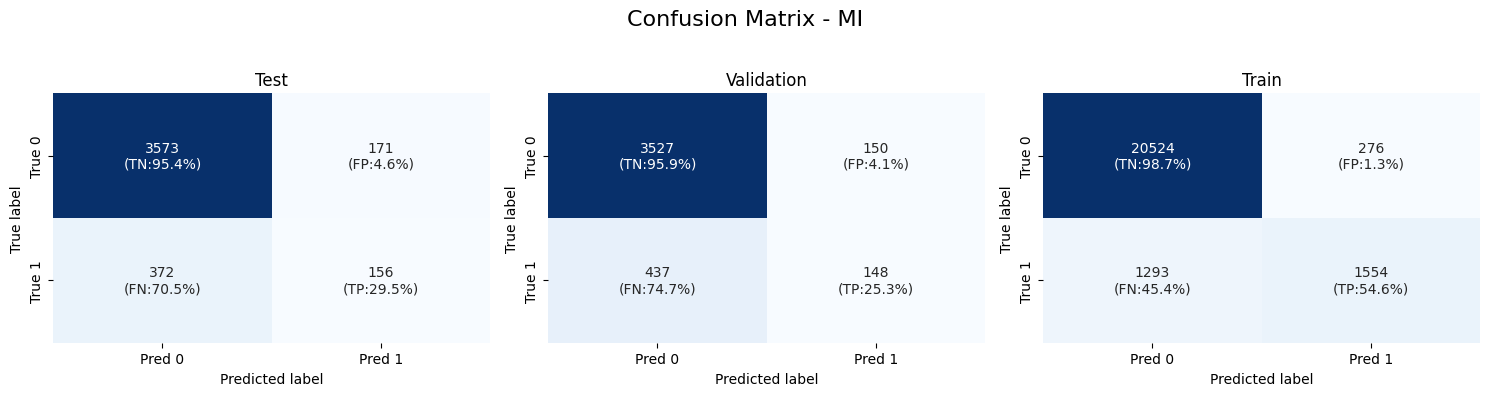

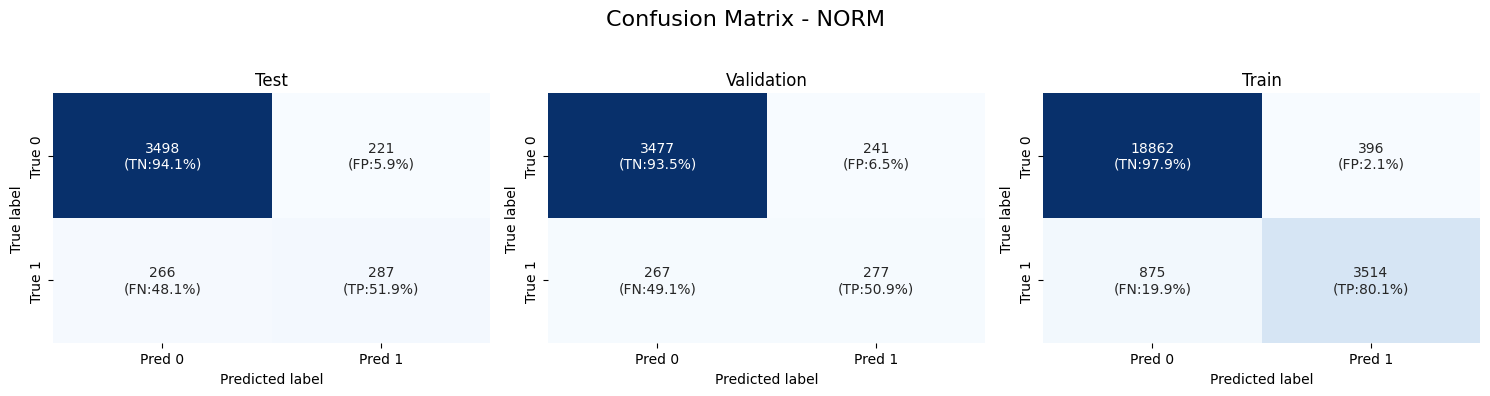

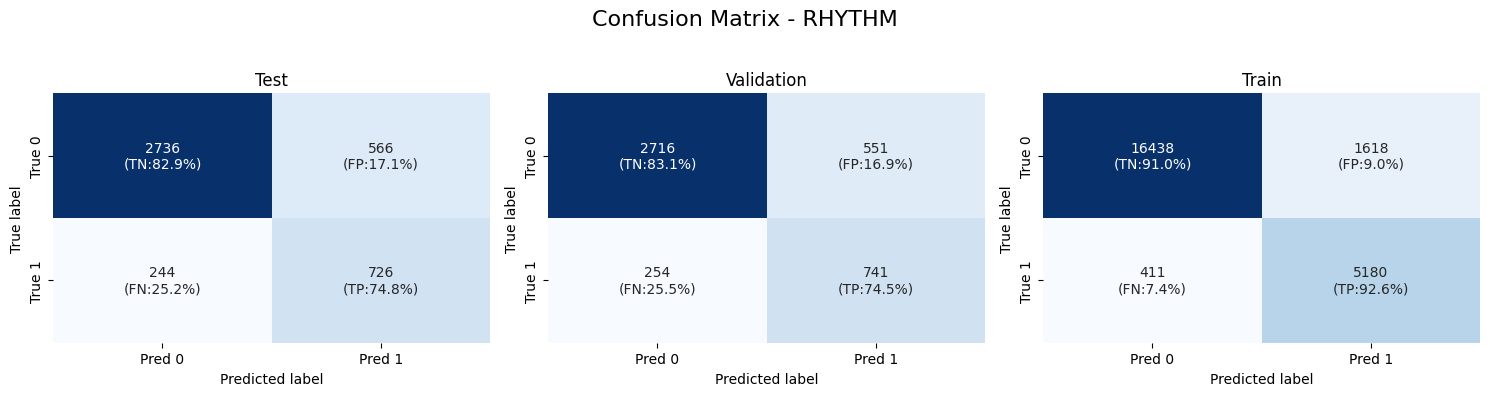

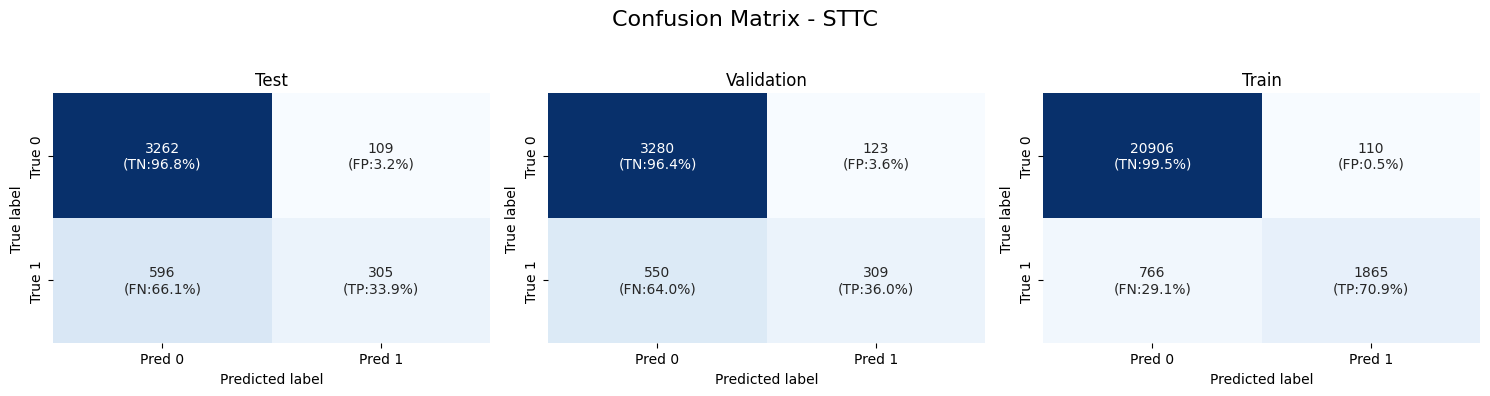

In [ ]:
print("confusion_matrix (Test Set)")
#plot_confusion_matrix_per_class(targets_test, preds_test, list(classes_name.keys()))
set_names = ["Test", "Validation", "Train"]
plot_confusion_matrix_per_class_multi(
    [targets_test, targets_val, targets_train],
    [preds_test, preds_val, preds_train],
    class_names=list(label_map.keys()),
    set_names=set_names
)